# langgraph class 2 - assignment flow
this notebook covers: supervisor, router, llm/rag/web nodes, validation loop, and final output

In [5]:
import operator
from typing import TypedDict, Annotated, Sequence
from pydantic import BaseModel, Field

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser
from langchain_core.runnables import RunnablePassthrough
from langgraph.graph import StateGraph, END

import requests

### config the model

In [2]:
model = ChatGoogleGenerativeAI(model='gemini-flash-lite-latest')
"model initialized"

'model initialized'

### config embedding + rag retriever

In [3]:
embeddings = HuggingFaceEmbeddings(model_name='BAAI/bge-small-en')
loader = DirectoryLoader('../data2', glob='./*.txt', loader_cls=TextLoader)
docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=50
)
new_docs = text_splitter.split_documents(documents=docs)

db = Chroma.from_documents(new_docs, embeddings)
retriever = db.as_retriever(search_kwargs={'k': 3})

In [6]:
def format_docs(docs):
    return '\n\n'.join(doc.page_content for doc in docs)

def web_search(query: str) -> str:
    try:
        response = requests.get(
            'https://api.duckduckgo.com/',
            params={
                'q': query,
                'format': 'json',
                'no_html': 1,
                'no_redirect': 1
            },
            timeout=15
        )
        payload = response.json()

        abstract = payload.get('AbstractText', '')
        related = payload.get('RelatedTopics', [])

        snippets = []
        if abstract:
            snippets.append(abstract)

        for item in related[:5]:
            if isinstance(item, dict):
                text = item.get('Text')
                if text:
                    snippets.append(text)

        if snippets:
            return ' | '.join(snippets)

        return 'No useful realtime result found from web search.'
    except Exception as error:
        return f'Web search failed: {error}'

### pydantic parsers

In [7]:
class RouteSelectionParser(BaseModel):
    route: str = Field(description='One of: RAG, WEB, LLM')
    reasoning: str = Field(description='Reasoning behind route selection')

route_parser = PydanticOutputParser(pydantic_object=RouteSelectionParser)

### state + nodes

In [8]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[str], operator.add]
    route: str
    draft_answer: str
    validation_passed: bool
    retries: int

In [9]:
def supervisor_node(state: AgentState):
    question = state['messages'][0]
    print('-> SUPERVISOR ->')
    print('question:', question)

    template = """
    You are a routing supervisor.
    Select only one route from: [RAG, WEB, LLM].
    Use WEB for latest/realtime/news/current info.
    Use RAG for USA/domain context from local vector DB.
    Use LLM for general knowledge.

    User query: {question}
    {format_instructions}
    """

    prompt = PromptTemplate(
        template=template,
        input_variables=['question'],
        partial_variables={'format_instructions': route_parser.get_format_instructions()}
    )

    chain = prompt | model | route_parser

    try:
        response = chain.invoke({'question': question})
        route = response.route.strip().upper()
        if route not in ['RAG', 'WEB', 'LLM']:
            route = 'LLM'
        print('selected route:', route)
    except Exception as error:
        question_l = question.lower()
        if any(k in question_l for k in ['latest', 'today', 'current', 'news', 'realtime', 'live']):
            route = 'WEB'
        elif any(k in question_l for k in ['usa', 'gdp', 'industrial growth', 'economy']):
            route = 'RAG'
        else:
            route = 'LLM'
        print('supervisor fallback route:', route)
        print('reason:', error)

    return {'route': route}

In [10]:
def router(state: AgentState):
    print('-> ROUTER ->')
    print('route:', state['route'])
    if state['route'] == 'RAG':
        return 'RAG'
    if state['route'] == 'WEB':
        return 'WEB'
    return 'LLM'

In [11]:
def llm_node(state: AgentState):
    print('-> LLM NODE ->')
    question = state['messages'][0]
    try:
        response = model.invoke('Answer this question clearly: ' + question)
        answer = response.content
    except Exception as error:
        print('LLM call failed:', error)
        answer = 'I cannot generate a live LLM answer right now due to model quota limits. Please retry after quota reset.'
    return {'draft_answer': answer}

In [12]:
def rag_node(state: AgentState):
    print('-> RAG NODE ->')
    question = state['messages'][0]

    prompt = PromptTemplate(
        template='''You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question}\nContext: {context}\nAnswer:''',
        input_variables=['context', 'question']
    )

    rag_chain = (
        {'context': retriever | format_docs, 'question': RunnablePassthrough()}
        | prompt
        | model
        | StrOutputParser()
    )

    try:
        answer = rag_chain.invoke(question)
    except Exception as error:
        print('RAG call failed:', error)
        answer = 'I cannot generate a live RAG answer right now due to model quota limits. Please retry after quota reset.'

    return {'draft_answer': answer}

In [18]:
def validation_node(state: AgentState):
    print('-> VALIDATION NODE ->')
    answer = state.get('draft_answer', '')
    retries = state.get('retries', 0) + 1

    is_empty = len(answer.strip()) == 0
    quota_text = 'quota limits' in answer.lower()
    too_short = len(answer.strip()) < 25

    passed = (not is_empty) and (not quota_text) and (not too_short)
    print('validation passed:', passed)

    return {
        'validation_passed': passed,
        'retries': retries
    }

In [14]:
def web_node(state: AgentState):
    print('-> WEB NODE ->')
    question = state['messages'][0]

    web_context = web_search(question)

    summarize_prompt = PromptTemplate(
        template='''Use the web context and answer briefly.\nQuestion: {question}\nWeb Context: {web_context}\nAnswer:''',
        input_variables=['question', 'web_context']
    )

    web_chain = summarize_prompt | model | StrOutputParser()

    try:
        answer = web_chain.invoke({'question': question, 'web_context': web_context})
    except Exception as error:
        print('Web summary model call failed:', error)
        answer = 'I cannot generate a live WEB answer right now due to model quota limits. Please retry after quota reset.'

    return {'draft_answer': answer}

In [15]:
def validation_router(state: AgentState):
    print('-> VALIDATION ROUTER ->')
    if state.get('validation_passed', False):
        return 'FINAL'

    if state.get('retries', 0) >= 2:
        return 'FINAL'

    return 'RETRY'

In [16]:
def final_node(state: AgentState):
    print('-> FINAL NODE ->')
    final_answer = state.get('draft_answer', 'No answer generated.')
    return {'messages': [final_answer]}

### graph wiring

In [23]:
workflow = StateGraph(AgentState)

workflow.add_node('Supervisor', supervisor_node)
workflow.add_node('RAG', rag_node)
workflow.add_node('WEB', web_node)
workflow.add_node('LLM', llm_node)
workflow.add_node('VALIDATION', validation_node)
workflow.add_node('FINAL', final_node)

workflow.set_entry_point('Supervisor')

workflow.add_conditional_edges(
    'Supervisor',
    router,
    {
        'RAG': 'RAG',
        'WEB': 'WEB',
        'LLM': 'LLM'
    }
)

workflow.add_edge('RAG', 'VALIDATION')
workflow.add_edge('WEB', 'VALIDATION')
workflow.add_edge('LLM', 'VALIDATION')

workflow.add_conditional_edges(
    'VALIDATION',
    validation_router,
    {
        'FINAL': 'FINAL',
        'RETRY': 'Supervisor'
    }
)

workflow.add_edge('FINAL', END)

app = workflow.compile()
'graph compiled'

'graph compiled'

In [25]:
from IPython.display import display, Markdown

mermaid_text = app.get_graph().draw_mermaid()
display(Markdown(f"```mermaid\n{mermaid_text}\n```"))
mermaid_text

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	Supervisor(Supervisor)
	RAG(RAG)
	WEB(WEB)
	LLM(LLM)
	VALIDATION(VALIDATION)
	FINAL(FINAL)
	__end__([<p>__end__</p>]):::last
	LLM --> VALIDATION;
	RAG --> VALIDATION;
	Supervisor -.-> LLM;
	Supervisor -.-> RAG;
	Supervisor -.-> WEB;
	VALIDATION -.-> FINAL;
	VALIDATION -. &nbsp;RETRY&nbsp; .-> Supervisor;
	WEB --> VALIDATION;
	__start__ --> Supervisor;
	FINAL --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

'---\nconfig:\n  flowchart:\n    curve: linear\n---\ngraph TD;\n\t__start__([<p>__start__</p>]):::first\n\tSupervisor(Supervisor)\n\tRAG(RAG)\n\tWEB(WEB)\n\tLLM(LLM)\n\tVALIDATION(VALIDATION)\n\tFINAL(FINAL)\n\t__end__([<p>__end__</p>]):::last\n\tLLM --> VALIDATION;\n\tRAG --> VALIDATION;\n\tSupervisor -.-> LLM;\n\tSupervisor -.-> RAG;\n\tSupervisor -.-> WEB;\n\tVALIDATION -.-> FINAL;\n\tVALIDATION -. &nbsp;RETRY&nbsp; .-> Supervisor;\n\tWEB --> VALIDATION;\n\t__start__ --> Supervisor;\n\tFINAL --> __end__;\n\tclassDef default fill:#f2f0ff,line-height:1.2\n\tclassDef first fill-opacity:0\n\tclassDef last fill:#bfb6fc\n'

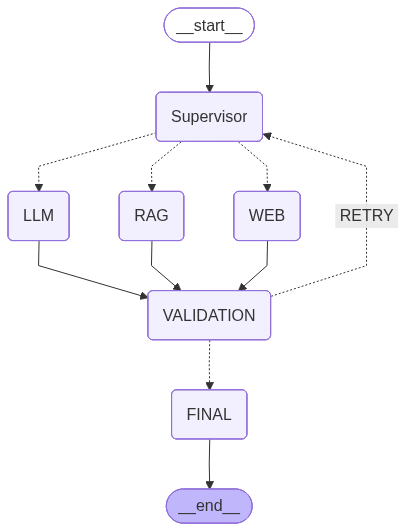

In [26]:
from IPython.display import Image, display

try:
    png_data = app.get_graph().draw_mermaid_png()
    display(Image(png_data))
    "PNG graph rendered"
except Exception as error:
    print("PNG render unavailable, keeping Mermaid text view.")
    print(error)

### graph legend
- **Supervisor**: selects route (`RAG`, `WEB`, or `LLM`)
- **LLM / RAG / WEB**: generate a draft answer
- **VALIDATION**: checks answer quality
- **VALIDATION → FINAL**: validation passed (or retry limit reached)
- **VALIDATION → Supervisor (RETRY)**: validation failed, route is chosen again

### run examples

In [20]:
state = {
    'messages': ['what is a gdp of usa?'],
    'route': '',
    'draft_answer': '',
    'validation_passed': False,
    'retries': 0
}
result = app.invoke(state)
result['messages'][-1]

-> SUPERVISOR ->
question: what is a gdp of usa?
supervisor fallback route: RAG
reason: Error calling model 'gemini-flash-lite-latest' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 44.07421434s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tie

'I cannot generate a live RAG answer right now due to model quota limits. Please retry after quota reset.'

In [21]:
state = {
    'messages': ['latest inflation update in usa'],
    'route': '',
    'draft_answer': '',
    'validation_passed': False,
    'retries': 0
}
result = app.invoke(state)
result['messages'][-1]

-> SUPERVISOR ->
question: latest inflation update in usa
supervisor fallback route: WEB
reason: Error calling model 'gemini-flash-lite-latest' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 4.846199855s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content

'I cannot generate a live WEB answer right now due to model quota limits. Please retry after quota reset.'

In [22]:
state = {
    'messages': ['explain reinforcement learning in simple words'],
    'route': '',
    'draft_answer': '',
    'validation_passed': False,
    'retries': 0
}
result = app.invoke(state)
result['messages'][-1]

-> SUPERVISOR ->
question: explain reinforcement learning in simple words
supervisor fallback route: LLM
reason: Error calling model 'gemini-flash-lite-latest' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 21.494574263s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com

'I cannot generate a live LLM answer right now due to model quota limits. Please retry after quota reset.'